# TERRA - DS Part 3 - EDA and Plots

**Input:** `../data/processed/terra_merged.csv`

**Year range:** 2010–2023

**Goal:** Explore the relationships between identified climate stressors and displacement across EU 27 member states.

**Outputs:** `../outputs/`

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

df = pd.read_csv("../datasets/processed/merged_data.csv")

df["asylum_per_100k"] = (df["asylum_applications"] / df["population"]) * 100_000

os.makedirs("../outputs", exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted")

print(df.shape)
df.head()

(378, 14)


,year,gdp_per_capita,unemployment_rate,population,urban_pct,country_code,asylum_applications,temp_mean,heatwave_days,precip_total,precip_days_heavy,dry_days,evapotrans_total,asylum_per_100k
0,2010,46611.139342,4.883,8363404.0,67.104743,AT,11060.0,9.422351,0,783.7,7,229,759.99400,132.242804
1,2011,51116.895352,4.637,8391643.0,67.148426,AT,14455.0,10.900239,0,498.1,2,277,873.22080,172.254706
2,2012,48250.405914,4.909,8429991.0,67.208591,AT,17450.0,11.087264,0,552.6,1,254,891.62646,206.999035
3,2013,50305.354577,5.367,8479823.0,67.298131,AT,17520.0,10.479536,2,709.0,4,237,810.21140,206.608086
4,2014,51314.972262,5.674,8546356.0,67.415433,AT,28065.0,11.703919,0,796.7,4,237,811.51587,328.385572


## 1. Exploring single variable statistics
Exploring distribution range for climate, economic and migration variables.

In [9]:
df[["asylum_per_100k", "temp_mean", "heatwave_days","dry_days", "gdp_per_capita", "unemployment_rate"]].describe().round(2)

,asylum_per_100k,temp_mean,heatwave_days,dry_days,gdp_per_capita,unemployment_rate
count,378.00,378.00,378.00,378.00,378.00,378.00
mean,161.70,11.75,2.25,248.06,35250.65,8.38
std,237.07,3.68,7.55,32.26,23870.79,4.54
min,0.00,4.73,0.00,172.00,6853.95,2.02
25%,15.98,9.43,0.00,225.00,18341.59,5.44
50%,76.36,11.14,0.00,243.00,27868.59,7.09
75%,222.34,12.58,0.00,268.75,48186.75,9.99
max,1807.91,21.12,54.00,324.00,134965.82,27.69


## 2. Statistical significance
Exploring if temperature significantly correlates with displacement.

In [12]:
r, p = stats.pearsonr(df["temp_mean"].dropna(), df["asylum_per_100k"].dropna())
print(f"Correlation: {r:.3f}")
print(f"P-value:     {p:.3f}")
print(f"Significant: {p < 0.05}")

Correlation: 0.260
P-value:     0.000
Significant: True


Judging by the statistical significance test, it shows a weak positive correlation between temperature mean and asylum per 100k. 

## 3. Correlation matrix
Two-variable summary between climate, economic and migration variables from cleaned data.

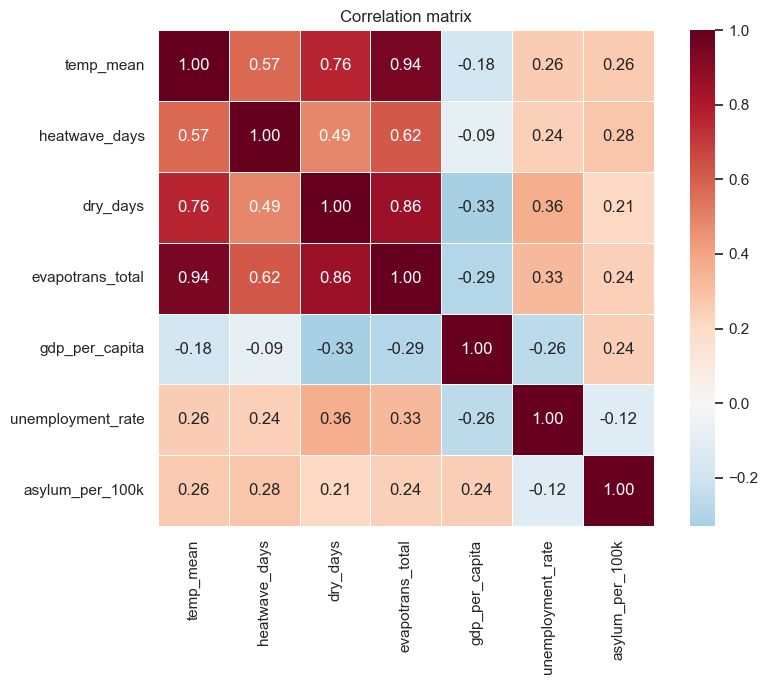

In [ ]:
cols = ["temp_mean", "heatwave_days", "dry_days", "evapotrans_total", "gdp_per_capita", "unemployment_rate", "asylum_per_100k"]

plt.figure(figsize=(9, 7))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=0.5)
plt.title("Correlation matrix")
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", dpi=150)
plt.show()

## 4. Country comparison
Exploring which countries face the highest displacement.

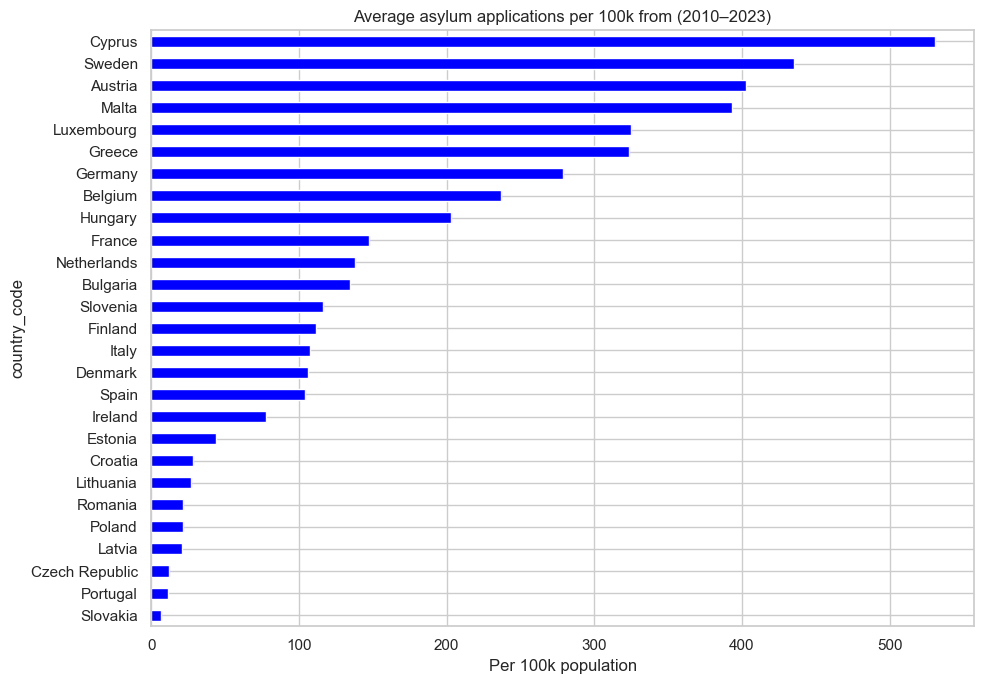

In [26]:
country_names = {
    "AT":"Austria","BE":"Belgium","BG":"Bulgaria","CY":"Cyprus",
    "CZ":"Czech Republic","DE":"Germany","DK":"Denmark","EE":"Estonia",
    "ES":"Spain","FI":"Finland","FR":"France","GR":"Greece",
    "HR":"Croatia","HU":"Hungary","IE":"Ireland","IT":"Italy",
    "LT":"Lithuania","LU":"Luxembourg","LV":"Latvia","MT":"Malta",
    "NL":"Netherlands","PL":"Poland","PT":"Portugal","RO":"Romania",
    "SE":"Sweden","SI":"Slovenia","SK":"Slovakia"
}

avg = df.groupby("country_code")["asylum_per_100k"].mean().sort_values()
avg.index = avg.index.map(country_names)

plt.figure(figsize=(10, 7))
avg.plot(kind="barh", color="blue")
plt.title("Average asylum applications per 100k from (2010–2023)")
plt.xlabel("Per 100k population")
plt.tight_layout()
plt.savefig("../outputs/country_averages.png", dpi=150)
plt.show()

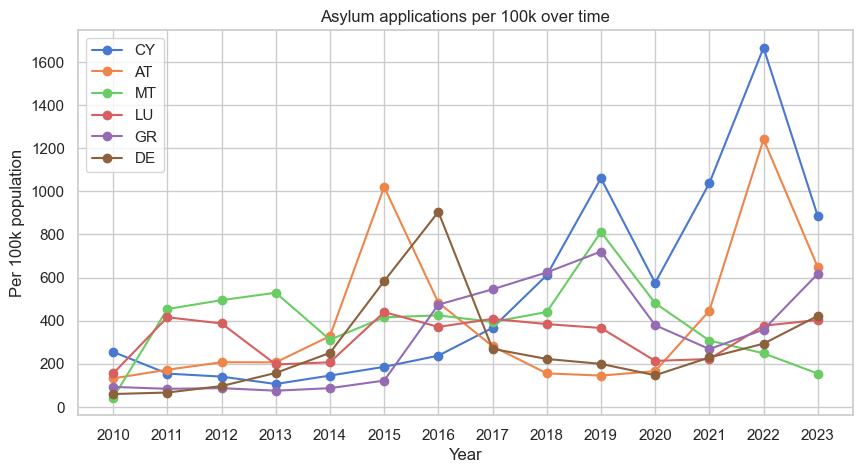

In [25]:
focus_group = ["CY", "AT","MT", "LU", "GR", "DE"] # Highest asylum rate applicants

plt.figure(figsize=(10, 5))

for countries in focus_group:
    sub = df[df["country_code"] == countries]
    plt.plot(sub["year"], sub["asylum_per_100k"], marker="o", label=countries)

plt.title("Asylum applications per 100k over time")
plt.xlabel("Year")
plt.ylabel("Per 100k population")
plt.legend()
plt.xticks(range(2010, 2024)) 
plt.savefig("../outputs/time_series.png", dpi=150)
plt.show()